In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
freq = pd.read_csv('../data/raw/freMTPL2freq.csv')
sev = pd.read_csv('../data/raw/freMTPL2sev.csv')

print("Frequency table shape:", freq.shape)
print("Severity table shape:", sev.shape)
print("\nFrequency columns:", freq.columns.tolist())
print("\nSeverity columns:", sev.columns.tolist())

Frequency table shape: (678013, 12)
Severity table shape: (26639, 2)

Frequency columns: ['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region']

Severity columns: ['IDpol', 'ClaimAmount']


In [3]:
# Look at the first 5 rows of each table
print("=== FREQUENCY TABLE (first 5 rows) ===")
print(freq.head())

print("\n=== SEVERITY TABLE (first 5 rows) ===")
print(sev.head())

print("\n=== FREQUENCY TABLE - Basic Info ===")
print(freq.describe())

=== FREQUENCY TABLE (first 5 rows) ===
   IDpol  ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus  \
0    1.0        1      0.10    D         5       0       55          50   
1    3.0        1      0.77    D         5       0       55          50   
2    5.0        1      0.75    B         6       2       52          50   
3   10.0        1      0.09    B         7       0       46          50   
4   11.0        1      0.84    B         7       0       46          50   

  VehBrand   VehGas  Density Region  
0      B12  Regular     1217    R82  
1      B12  Regular     1217    R82  
2      B12   Diesel       54    R22  
3      B12   Diesel       76    R72  
4      B12   Diesel       76    R72  

=== SEVERITY TABLE (first 5 rows) ===
     IDpol  ClaimAmount
0     1552       995.20
1  1010996      1128.12
2  4024277      1851.11
3  4007252      1204.00
4  4046424      1204.00

=== FREQUENCY TABLE - Basic Info ===
              IDpol        ClaimNb       Exposure       VehPo

In [4]:
print("=== MISSING VALUES - FREQUENCY TABLE ===")
print(freq.isnull().sum())

print("\n=== MISSING VALUES - SEVERITY TABLE ===")
print(sev.isnull().sum())

=== MISSING VALUES - FREQUENCY TABLE ===
IDpol         0
ClaimNb       0
Exposure      0
Area          0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Density       0
Region        0
dtype: int64

=== MISSING VALUES - SEVERITY TABLE ===
IDpol          0
ClaimAmount    0
dtype: int64


In [5]:
# Merge the two tables
df = freq.merge(sev, on='IDpol', how='left')

print("Merged table shape:", df.shape)
print("\nMissing ClaimAmount after merge:", df['ClaimAmount'].isnull().sum())
print("\nFirst 5 rows:")
print(df.head())

Merged table shape: (679513, 13)

Missing ClaimAmount after merge: 653069

First 5 rows:
   IDpol  ClaimNb  Exposure Area  VehPower  VehAge  DrivAge  BonusMalus  \
0    1.0        1      0.10    D         5       0       55          50   
1    3.0        1      0.77    D         5       0       55          50   
2    5.0        1      0.75    B         6       2       52          50   
3   10.0        1      0.09    B         7       0       46          50   
4   11.0        1      0.84    B         7       0       46          50   

  VehBrand   VehGas  Density Region  ClaimAmount  
0      B12  Regular     1217    R82          NaN  
1      B12  Regular     1217    R82          NaN  
2      B12   Diesel       54    R22          NaN  
3      B12   Diesel       76    R72          NaN  
4      B12   Diesel       76    R72          NaN  


In [7]:
# Fill missing ClaimAmount with 0 (no claim = 0 loss)
df['ClaimAmount'] = df['ClaimAmount'].fillna(0)

# Create two key columns for analysis
df['HasClaim'] = (df['ClaimNb'] > 0).astype(int)
df['PurePremiun'] = df['ClaimAmount'] / df['Exposure']

print("Claim rate:", round(df['HasClaim'].mean() * 100, 2), "%")
print("Average Claim Amount (where claim > 0):", round(df[df['ClaimAmount'] > 0]['ClaimAmount'].mean(), 2))
print("Shape:", df.shape)

Claim rate: 5.23 %
Average Claim Amount (where claim > 0): 2265.51
Shape: (679513, 15)


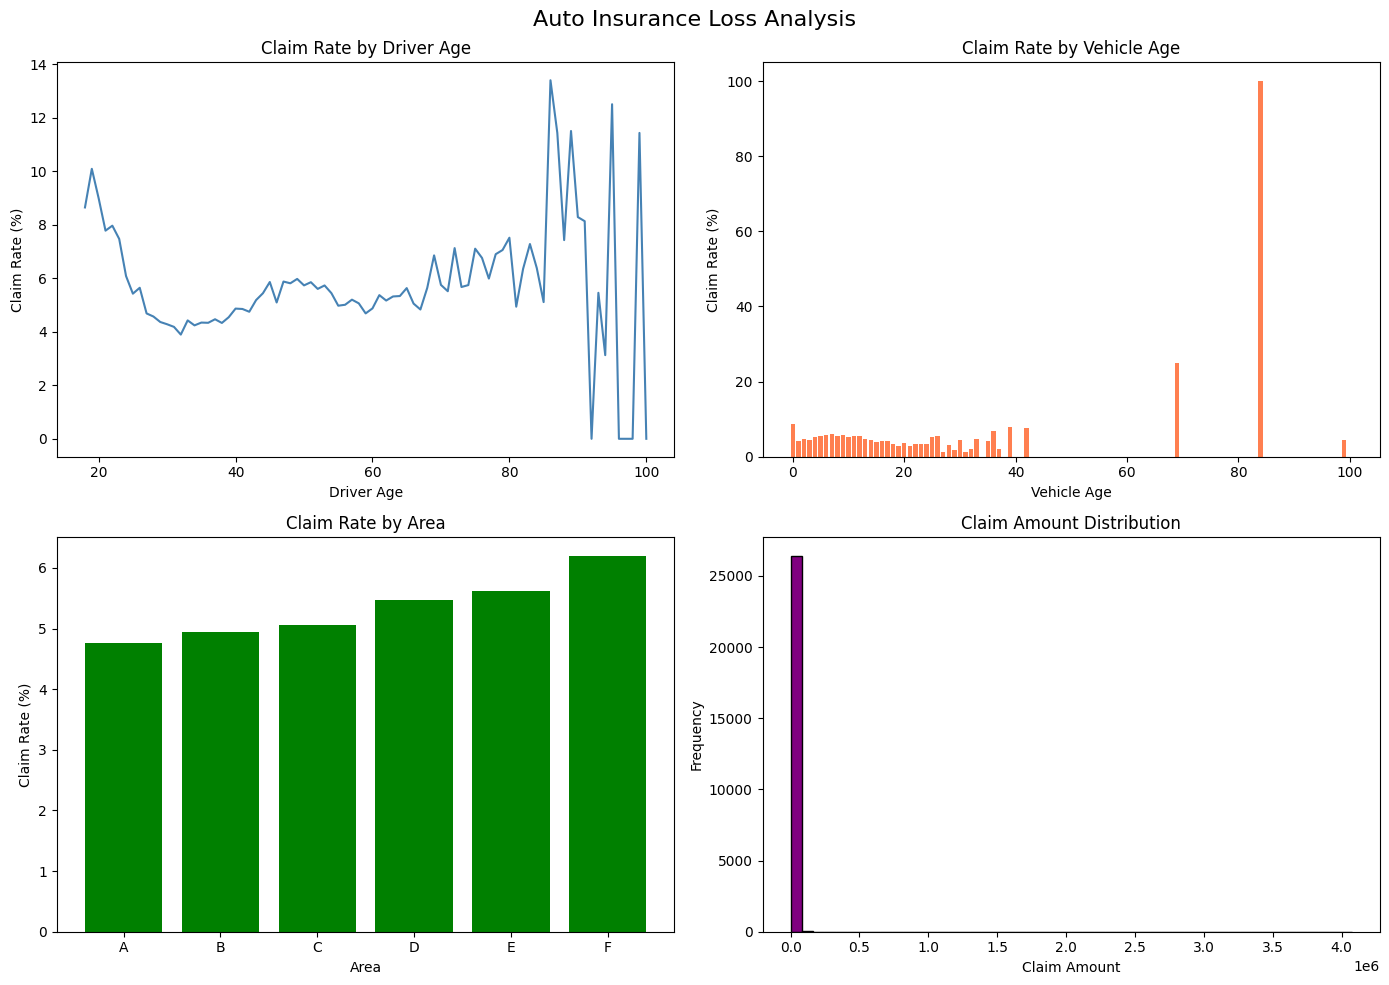

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Auto Insurance Loss Analysis', fontsize=16)

# 1. Claim rate by Driver Age
age_claims = df.groupby('DrivAge')['HasClaim'].mean() * 100
axes[0,0].plot(age_claims.index, age_claims.values, color='steelblue')
axes[0,0].set_title('Claim Rate by Driver Age')
axes[0,0].set_xlabel('Driver Age')
axes[0,0].set_ylabel('Claim Rate (%)')

# 2. Claim rate by Vehicle Age
vehage_claims = df.groupby('VehAge')['HasClaim'].mean() * 100
axes[0,1].bar(vehage_claims.index, vehage_claims.values, color='coral')
axes[0,1].set_title('Claim Rate by Vehicle Age')
axes[0,1].set_xlabel('Vehicle Age')
axes[0,1].set_ylabel('Claim Rate (%)')

# 3. Claim rate by Area
area_claims = df.groupby('Area')['HasClaim'].mean() * 100
axes[1,0].bar(area_claims.index, area_claims.values, color='green')
axes[1,0].set_title('Claim Rate by Area')
axes[1,0].set_xlabel('Area')
axes[1,0].set_ylabel('Claim Rate (%)')

# 4. Claim Amount Distribution
claims_only = df[df['ClaimAmount'] > 0]['ClaimAmount']
axes[1,1].hist(claims_only, bins=50, color='purple', edgecolor='black')
axes[1,1].set_title('Claim Amount Distribution')
axes[1,1].set_xlabel('Claim Amount')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [9]:
# Exposure-weighted statistics per variable
print("=== EXPOSURE-WEIGHTED CLAIM FREQUENCY BY DRIVER AGE GROUP ===")
df['AgeGroup'] = pd.cut(df['DrivAge'], bins=[17,25,35,50,65,100], labels=['18-25','26-35','36-50','51-65','65+'])
age_summary = df.groupby('AgeGroup', observed=True).agg(
    Policies=('IDpol','count'),
    Total_Exposure=('Exposure','sum'),
    Total_Claims=('ClaimNb','sum'),
    Total_Losses=('ClaimAmount','sum')
).assign(
    Claim_Frequency=lambda x: x['Total_Claims']/x['Total_Exposure'],
    Avg_Severity=lambda x: x['Total_Losses']/x['Total_Claims'].replace(0,1),
    Pure_Premium=lambda x: x['Total_Losses']/x['Total_Exposure']
).round(2)
print(age_summary)

=== EXPOSURE-WEIGHTED CLAIM FREQUENCY BY DRIVER AGE GROUP ===
          Policies  Total_Exposure  Total_Claims  Total_Losses  \
AgeGroup                                                         
18-25        39077        16333.83          3235   12307261.54   
26-35       149464        69451.09          7258   10607248.80   
36-50       252170       132326.38         14116   18329702.08   
51-65       171657        97025.63         10649   12383419.68   
65+          67145        44378.30          4530    6281584.40   

          Claim_Frequency  Avg_Severity  Pure_Premium  
AgeGroup                                               
18-25                0.20       3804.41        753.48  
26-35                0.10       1461.46        152.73  
36-50                0.11       1298.51        138.52  
51-65                0.11       1162.87        127.63  
65+                  0.10       1386.66        141.55  


In [10]:
print(f"Row count: {len(df):,}")
print(f"Total policies: {df['IDpol'].nunique():,}")
print(f"Duplicate policy IDs: {len(df) - df['IDpol'].nunique():,}")
print(f"Total ClaimNb in df: {int(df['ClaimNb'].sum()):,}")

Row count: 679,513
Total policies: 678,013
Duplicate policy IDs: 1,500
Total ClaimNb in df: 39,788


In [11]:
# Fix: aggregate severity first, then merge
sev_agg = sev.groupby('IDpol')['ClaimAmount'].sum().reset_index()

# Rebuild the merged dataframe cleanly
df = freq.merge(sev_agg, on='IDpol', how='left')
df['ClaimAmount'] = df['ClaimAmount'].fillna(0)
df['HasClaim'] = (df['ClaimNb'] > 0).astype(int)
df['PurePremium'] = df['ClaimAmount'] / df['Exposure']
df['AgeGroup'] = pd.cut(df['DrivAge'], bins=[17,25,35,50,65,100], labels=['18-25','26-35','36-50','51-65','65+'])

# Verify fix
print(f"Row count: {len(df):,}")
print(f"Total policies: {df['IDpol'].nunique():,}")
print(f"Duplicate policy IDs: {len(df) - df['IDpol'].nunique():,}")
print(f"Total ClaimNb in df: {int(df['ClaimNb'].sum()):,}")

Row count: 678,013
Total policies: 678,013
Duplicate policy IDs: 0
Total ClaimNb in df: 36,102


In [13]:
BASE_RATE = 500

df['SyntheticPremium'] = BASE_RATE * (df['BonusMalus'] / 100) * df['Exposure']

total_premium = df['SyntheticPremium'].sum()
total_losses = df['ClaimAmount'].sum()
total_claims = df['ClaimNb'].sum()
total_exposure = df['Exposure'].sum()

loss_ratio = total_losses / total_premium
frequency = total_claims / total_exposure
severity = total_losses / total_claims
pure_premium = total_losses / total_exposure

print("=== BOOK-LEVEL METRICS ===")
print("Total Policies:      ", len(df))
print("Total Exposure:      ", round(total_exposure, 1))
print("Total Claims:        ", int(total_claims))
print("Total Losses:        ", round(total_losses, 0))
print("Total Premium:       ", round(total_premium, 0))
print("Loss Ratio:          ", round(loss_ratio * 100, 2), "%")
print("Claim Frequency:     ", round(frequency, 4))
print("Claim Severity:      ", round(severity, 2))
print("Pure Premium:        ", round(pure_premium, 2))
print("Freq x Sev:          ", round(frequency * severity, 2))

=== BOOK-LEVEL METRICS ===
Total Policies:       678013
Total Exposure:       358499.4
Total Claims:         36102
Total Losses:         59909216.0
Total Premium:        103586653.0
Loss Ratio:           57.83 %
Claim Frequency:      0.1007
Claim Severity:       1659.44
Pure Premium:         167.11
Freq x Sev:           167.11


In [14]:
print("=== PURE PREMIUM DECOMPOSITION ===")
print("Pure Premium = Frequency x Severity")
print(round(frequency, 4), "x", round(severity, 2), "=", round(pure_premium, 2))
print("")
print("=== ASSUMPTION NOTE (for your memo) ===")
print("Synthetic premium = 500 x (BonusMalus/100) x Exposure")
print("Base rate of 500 euros is assumed. Loss ratio will shift with base rate.")
print("At base rate 400:", round((total_losses / (400 * (df['BonusMalus']/100) * df['Exposure']).sum()) * 100, 2), "%")
print("At base rate 500:", round(loss_ratio * 100, 2), "%")
print("At base rate 600:", round((total_losses / (600 * (df['BonusMalus']/100) * df['Exposure']).sum()) * 100, 2), "%")

=== PURE PREMIUM DECOMPOSITION ===
Pure Premium = Frequency x Severity
0.1007 x 1659.44 = 167.11

=== ASSUMPTION NOTE (for your memo) ===
Synthetic premium = 500 x (BonusMalus/100) x Exposure
Base rate of 500 euros is assumed. Loss ratio will shift with base rate.
At base rate 400: 72.29 %
At base rate 500: 57.83 %
At base rate 600: 48.2 %


In [15]:
# Bucket continuous variables
df['AgeGroup'] = pd.cut(df['DrivAge'], bins=[17,25,35,50,65,100],
                         labels=['18-25','26-35','36-50','51-65','65+'])
df['VehAgeGroup'] = pd.cut(df['VehAge'], bins=[-1,2,5,10,110],
                            labels=['0-2yrs','3-5yrs','6-10yrs','11+yrs'])

def segment_summary(groupby_col):
    return df.groupby(groupby_col, observed=True).agg(
        Policies=('IDpol','count'),
        Exposure=('Exposure','sum'),
        Claims=('ClaimNb','sum'),
        Losses=('ClaimAmount','sum'),
        Premium=('SyntheticPremium','sum')
    ).assign(
        Frequency=lambda x: (x['Claims']/x['Exposure']).round(4),
        Severity=lambda x: (x['Losses']/x['Claims'].replace(0,1)).round(2),
        LossRatio=lambda x: (x['Losses']/x['Premium']*100).round(2)
    )

print("=== LOSS RATIO BY DRIVER AGE ===")
print(segment_summary('AgeGroup'))
print("\n=== LOSS RATIO BY VEHICLE AGE ===")
print(segment_summary('VehAgeGroup'))
print("\n=== LOSS RATIO BY AREA ===")
print(segment_summary('Area'))

=== LOSS RATIO BY DRIVER AGE ===
          Policies       Exposure  Claims       Losses       Premium  \
AgeGroup                                                               
18-25        38895   16227.903263    2841  12307261.54  7.079922e+06   
26-35       149183   69266.778075    6662  10607248.80  2.290001e+07   
36-50       251693  131989.064958   13118  18329702.08  3.641951e+07   
51-65       171249   96757.600999    9283  12383419.68  2.565884e+07   
65+          66993   44258.098168    4198   6281584.40  1.152837e+07   

          Frequency  Severity  LossRatio  
AgeGroup                                  
18-25        0.1751   4332.02     173.83  
26-35        0.0962   1592.20      46.32  
36-50        0.0994   1397.29      50.33  
51-65        0.0959   1333.99      48.26  
65+          0.0949   1496.33      54.49  

=== LOSS RATIO BY VEHICLE AGE ===
             Policies       Exposure  Claims       Losses       Premium  \
VehAgeGroup                                        

In [16]:
# Pareto analysis - what % of losses come from top loss policies
df_sorted = df.sort_values('ClaimAmount', ascending=False).copy()
df_sorted['CumLosses'] = df_sorted['ClaimAmount'].cumsum()
df_sorted['CumLossPct'] = df_sorted['CumLosses'] / total_losses * 100
df_sorted['PolicyRank'] = range(1, len(df_sorted)+1)
df_sorted['PolicyPct'] = df_sorted['PolicyRank'] / len(df_sorted) * 100

# Find what % of losses top 1%, 5%, 10%, 20% of policies account for
for pct in [1, 5, 10, 20]:
    cutoff = df_sorted[df_sorted['PolicyPct'] <= pct]['CumLossPct'].max()
    print(f"Top {pct}% of policies account for {cutoff:.1f}% of total losses")

Top 1% of policies account for 73.9% of total losses
Top 5% of policies account for 100.0% of total losses
Top 10% of policies account for 100.0% of total losses
Top 20% of policies account for 100.0% of total losses


In [17]:
# Pareto on claims-only policies
df_claims = df[df['ClaimAmount'] > 0].sort_values('ClaimAmount', ascending=False).copy()
df_claims['CumLosses'] = df_claims['ClaimAmount'].cumsum()
df_claims['CumLossPct'] = df_claims['CumLosses'] / total_losses * 100
df_claims['PolicyRank'] = range(1, len(df_claims)+1)
df_claims['PolicyPct'] = df_claims['PolicyRank'] / len(df_claims) * 100

print(f"Total policies with claims: {len(df_claims):,}")
print(f"Total policies overall: {len(df):,}")
print("")

for pct in [1, 5, 10, 20]:
    cutoff = df_claims[df_claims['PolicyPct'] <= pct]['CumLossPct'].max()
    print(f"Top {pct}% of claimants account for {cutoff:.1f}% of total losses")

print("")
top20 = df_claims[df_claims['PolicyPct'] <= 20]
print(f"Top 20% of claimants = {len(top20):,} policies")
print(f"Their average claim: ${top20['ClaimAmount'].mean():,.0f}")
print(f"Bottom 80% average claim: ${df_claims[df_claims['PolicyPct'] > 20]['ClaimAmount'].mean():,.0f}")

Total policies with claims: 24,944
Total policies overall: 678,013

Top 1% of claimants account for 37.9% of total losses
Top 5% of claimants account for 52.3% of total losses
Top 10% of claimants account for 60.2% of total losses
Top 20% of claimants account for 69.6% of total losses

Top 20% of claimants = 4,988 policies
Their average claim: $8,355
Bottom 80% average claim: $914


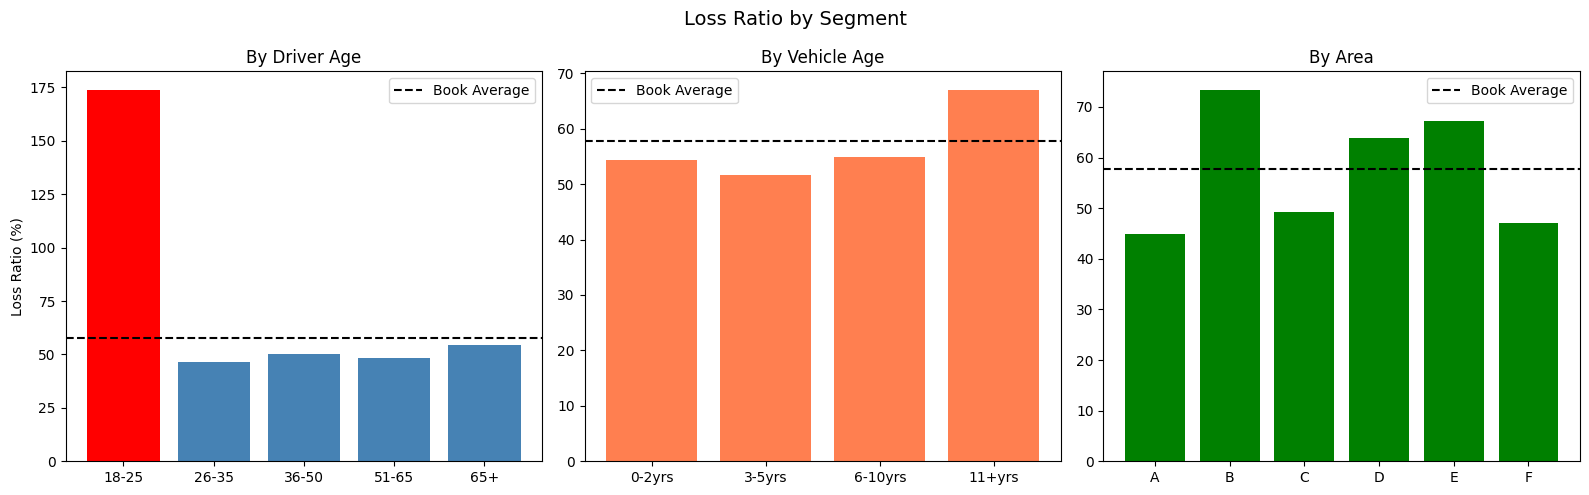

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Loss Ratio by Segment', fontsize=14)

# Driver Age
age_data = segment_summary('AgeGroup')
axes[0].bar(age_data.index, age_data['LossRatio'], color=['red' if x > 100 else 'steelblue' for x in age_data['LossRatio']])
axes[0].axhline(y=57.83, color='black', linestyle='--', label='Book Average')
axes[0].set_title('By Driver Age')
axes[0].set_ylabel('Loss Ratio (%)')
axes[0].legend()

# Vehicle Age
veh_data = segment_summary('VehAgeGroup')
axes[1].bar(veh_data.index, veh_data['LossRatio'], color='coral')
axes[1].axhline(y=57.83, color='black', linestyle='--', label='Book Average')
axes[1].set_title('By Vehicle Age')
axes[1].legend()

# Area
area_data = segment_summary('Area')
axes[2].bar(area_data.index, area_data['LossRatio'], color='green')
axes[2].axhline(y=57.83, color='black', linestyle='--', label='Book Average')
axes[2].set_title('By Area')
axes[2].legend()

plt.tight_layout()
plt.show()

In [2]:
import os
import pandas as pd

print("Working directory:", os.getcwd())
print()

# Try to find your processed file in the most likely locations
possible_paths = [
    '../data/processed/policies_with_premium.csv',
    'data/processed/policies_with_premium.csv',
    '../../data/processed/policies_with_premium.csv',
]

df = None
for path in possible_paths:
    try:
        df = pd.read_csv(path)
        print(f"✓ Loaded processed file from: {path}")
        break
    except FileNotFoundError:
        continue

if df is None:
    print("✗ Could not find processed file. Let's load the raw files instead.")
    # Fallback: rebuild from raw
    raw_paths_freq = ['../data/raw/freMTPL2freq.csv', 'data/raw/freMTPL2freq.csv']
    raw_paths_sev  = ['../data/raw/freMTPL2sev.csv',  'data/raw/freMTPL2sev.csv']
    
    freq, sev = None, None
    for p in raw_paths_freq:
        try:
            freq = pd.read_csv(p)
            print(f"  ✓ Loaded freq from: {p}")
            break
        except FileNotFoundError:
            continue
    for p in raw_paths_sev:
        try:
            sev = pd.read_csv(p)
            print(f"  ✓ Loaded sev from: {p}")
            break
        except FileNotFoundError:
            continue
    
    if freq is not None and sev is not None:
        # Aggregate severity to one row per policy (this fixes the duplicate row issue)
        sev_by_pol = sev.groupby('IDpol', as_index=False)['ClaimAmount'].sum()
        sev_by_pol.rename(columns={'ClaimAmount': 'TotalClaimAmount'}, inplace=True)
        df = freq.merge(sev_by_pol, on='IDpol', how='left')
        df['TotalClaimAmount'] = df['TotalClaimAmount'].fillna(0)
        print(f"  ✓ Rebuilt merged dataframe")

if df is not None:
    print()
    print("Columns:", df.columns.tolist())
    print(f"Row count: {len(df):,}")
    print(f"Unique policies: {df['IDpol'].nunique():,}")

Working directory: c:\auto-insurance-loss-analysis\notebooks

✓ Loaded processed file from: ../data/processed/policies_with_premium.csv

Columns: ['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region', 'TotalClaimAmount', 'Premium', 'AgeBucket', 'VehAgeBucket']
Row count: 678,013
Unique policies: 678,013


In [3]:
# ============================================================
# PHASE 5 DIAGNOSTIC — Print everything we need for recommendations
# ============================================================
import pandas as pd

# ---------- SECTION 1: BOOK-LEVEL METRICS ----------
total_exposure = df['Exposure'].sum()
total_claims   = df['ClaimNb'].sum()
total_losses   = df['TotalClaimAmount'].sum()
total_premium  = df['Premium'].sum()

book_frequency  = total_claims / total_exposure
book_severity   = total_losses / total_claims
book_loss_ratio = total_losses / total_premium

print("=" * 60)
print("BOOK-LEVEL METRICS")
print("=" * 60)
print(f"Total Exposure:  {total_exposure:>15,.0f} policy-years")
print(f"Total Claims:    {total_claims:>15,.0f}")
print(f"Total Losses:    €{total_losses:>14,.0f}")
print(f"Total Premium:   €{total_premium:>14,.0f}")
print("-" * 60)
print(f"Loss Ratio:      {book_loss_ratio:>15.1%}")
print(f"Frequency:       {book_frequency:>15.4f} claims/year")
print(f"Severity:        €{book_severity:>14,.0f} per claim")
print()


# ---------- SECTION 2: SEGMENT ANALYSIS ----------
def segment_table(df, segment_col):
    """Compute loss ratio, frequency, severity per segment."""
    seg = df.groupby(segment_col, observed=True).agg(
        exposure = ('Exposure', 'sum'),
        claims   = ('ClaimNb', 'sum'),
        losses   = ('TotalClaimAmount', 'sum'),
        premium  = ('Premium', 'sum'),
        policies = ('IDpol', 'count'),
    )
    seg['frequency']  = seg['claims']  / seg['exposure']
    seg['severity']   = seg['losses']  / seg['claims'].replace(0, pd.NA)
    seg['loss_ratio'] = seg['losses']  / seg['premium']
    return seg.sort_values('loss_ratio', ascending=False)

for col in ['AgeBucket', 'VehAgeBucket', 'Area', 'VehGas']:
    print("=" * 60)
    print(f"SEGMENT ANALYSIS: {col}")
    print("=" * 60)
    seg = segment_table(df, col)
    # Format for readability
    display_seg = seg[['policies', 'exposure', 'loss_ratio', 'frequency', 'severity']].copy()
    display_seg['exposure']   = display_seg['exposure'].round(0).astype(int)
    display_seg['loss_ratio'] = (display_seg['loss_ratio'] * 100).round(1).astype(str) + '%'
    display_seg['frequency']  = display_seg['frequency'].round(4)
    display_seg['severity']   = display_seg['severity'].round(0)
    print(display_seg.to_string())
    print()


# ---------- SECTION 3: PARETO ANALYSIS ----------
print("=" * 60)
print("PARETO ANALYSIS — Concentration of losses")
print("=" * 60)
sorted_losses = df['TotalClaimAmount'].sort_values(ascending=False).reset_index(drop=True)
cumulative_losses = sorted_losses.cumsum()
total = sorted_losses.sum()

for pct in [0.01, 0.05, 0.10, 0.20, 0.50]:
    n_policies = int(len(df) * pct)
    share_of_losses = cumulative_losses.iloc[n_policies - 1] / total
    print(f"Worst {pct*100:>4.0f}% of policies ({n_policies:>7,} policies) "
          f"= {share_of_losses*100:>5.1f}% of total losses")

# Bonus: what % of policies have zero claims?
pct_zero = (df['TotalClaimAmount'] == 0).mean() * 100
print()
print(f"Policies with ZERO claims: {pct_zero:.1f}%")
print(f"Policies with at least one claim: {100 - pct_zero:.1f}%")

BOOK-LEVEL METRICS
Total Exposure:          358,499 policy-years
Total Claims:             36,102
Total Losses:    €    59,909,216
Total Premium:   €   103,586,653
------------------------------------------------------------
Loss Ratio:                57.8%
Frequency:                0.1007 claims/year
Severity:        €         1,659 per claim

SEGMENT ANALYSIS: AgeBucket
           policies  exposure loss_ratio  frequency  severity
AgeBucket                                                    
18-25         38895     16228     173.8%     0.1751    4332.0
65+           66993     44258      54.5%     0.0949    1496.0
36-50        251693    131989      50.3%     0.0994    1397.0
51-65        171249     96758      48.3%     0.0959    1334.0
26-35        149183     69267      46.3%     0.0962    1592.0

SEGMENT ANALYSIS: VehAgeBucket
              policies  exposure loss_ratio  frequency  severity
VehAgeBucket                                                    
11+             185782    108

In [5]:
# Show me the segments that were cut off
for col in ['VehAgeBucket', 'Area', 'VehGas']:
    print("=" * 60)
    print(f"SEGMENT: {col}")
    print("=" * 60)
    seg = segment_table(df, col)
    display_seg = seg[['policies', 'exposure', 'loss_ratio', 'frequency', 'severity']].copy()
    display_seg['exposure']   = display_seg['exposure'].round(0).astype(int)
    display_seg['loss_ratio'] = (display_seg['loss_ratio'] * 100).round(1).astype(str) + '%'
    display_seg['frequency']  = display_seg['frequency'].round(4)
    display_seg['severity']   = display_seg['severity'].round(0)
    print(display_seg.to_string())
    print()

# And the Pareto numbers focused on policies WITH claims
print("=" * 60)
print("PARETO — among policies with at least one claim")
print("=" * 60)
df_with_claims = df[df['TotalClaimAmount'] > 0].copy()
sorted_losses = df_with_claims['TotalClaimAmount'].sort_values(ascending=False).reset_index(drop=True)
cumulative_losses = sorted_losses.cumsum()
total = sorted_losses.sum()
n_total = len(df_with_claims)

print(f"Total policies with claims: {n_total:,}")
print()
for pct in [0.01, 0.05, 0.10, 0.20, 0.50]:
    n_policies = max(1, int(n_total * pct))
    share = cumulative_losses.iloc[n_policies - 1] / total
    n_of_book = n_policies / len(df) * 100
    print(f"Worst {pct*100:>4.0f}% of CLAIMANTS ({n_policies:>6,} policies, "
          f"{n_of_book:.2f}% of book) = {share*100:>5.1f}% of losses")
    

    

SEGMENT: VehAgeBucket
              policies  exposure loss_ratio  frequency  severity
VehAgeBucket                                                    
11+             185782    108274      67.0%     0.0795    2469.0
6-10            171594     99009      54.9%     0.0994    1605.0
0-2             188147     79176      54.4%     0.1377    1128.0
3-5             132490     72040      51.6%     0.0936    1565.0

SEGMENT: Area
      policies  exposure loss_ratio  frequency  severity
Area                                                    
B        75459     43012      73.4%     0.0883    2335.0
E       137167     63819      67.3%     0.1223    1668.0
D       151596     77120      63.8%     0.1093    1719.0
C       191880    104449      49.2%     0.0945    1480.0
F        17954      8129      47.0%     0.1391    1043.0
A       103957     61969      44.9%     0.0817    1529.0

SEGMENT: VehGas
         policies  exposure loss_ratio  frequency  severity
VehGas                                  

In [7]:
# ============================================================
# PHASE 5 — RECOMMENDATION IMPACT MODEL
# ============================================================

# Baseline (current state)
baseline_premium = df['Premium'].sum()
baseline_losses  = df['TotalClaimAmount'].sum()
baseline_lr      = baseline_losses / baseline_premium

print(f"BASELINE")
print(f"  Premium:    €{baseline_premium:>15,.0f}")
print(f"  Losses:     €{baseline_losses:>15,.0f}")
print(f"  Loss Ratio: {baseline_lr:>15.1%}")
print()

# ---------- ACTION 1: Re-price DrivAge 18-25 by +40% ----------
RATE_INCREASE = 0.40
RETENTION_18_25 = 0.60

action1 = df.copy()

# Cast integer columns to float so we can multiply by 0.6 without errors
# This is a simulation, fractional values represent expected outcomes
action1['ClaimNb']  = action1['ClaimNb'].astype(float)
action1['Exposure'] = action1['Exposure'].astype(float)
action1['Premium']  = action1['Premium'].astype(float)
action1['TotalClaimAmount'] = action1['TotalClaimAmount'].astype(float)

# Identify the segment
mask_18_25 = action1['AgeBucket'] == '18-25'

# Apply: 40% of these policies leave (retention loss)
# Exposure, claims, and losses all drop by 40%
action1.loc[mask_18_25, 'Exposure']         *= RETENTION_18_25
action1.loc[mask_18_25, 'ClaimNb']          *= RETENTION_18_25
action1.loc[mask_18_25, 'TotalClaimAmount'] *= RETENTION_18_25
# The 60% who STAY pay 40% more — so segment premium = 0.60 × 1.40 = 0.84 of original
action1.loc[mask_18_25, 'Premium']          *= RETENTION_18_25 * (1 + RATE_INCREASE)

action1_premium = action1['Premium'].sum()
action1_losses  = action1['TotalClaimAmount'].sum()
action1_lr      = action1_losses / action1_premium

print(f"ACTION 1: Re-price DrivAge 18-25 by +{RATE_INCREASE:.0%}, assume {RETENTION_18_25:.0%} retention")
print(f"  Premium:    €{action1_premium:>15,.0f}  ({(action1_premium - baseline_premium):+,.0f})")
print(f"  Losses:     €{action1_losses:>15,.0f}  ({(action1_losses - baseline_losses):+,.0f})")
print(f"  Loss Ratio: {action1_lr:>15.1%}  ({(action1_lr - baseline_lr)*100:+.1f} pts)")

BASELINE
  Premium:    €    103,586,653
  Losses:     €     59,909,216
  Loss Ratio:           57.8%

ACTION 1: Re-price DrivAge 18-25 by +40%, assume 60% retention
  Premium:    €    102,453,866  (-1,132,788)
  Losses:     €     54,986,312  (-4,922,905)
  Loss Ratio:           53.7%  (-4.2 pts)


In [9]:
# ---------- ACTION 2: Tighten underwriting in Area B ----------
# Severity-driven problem — re-pricing won't fix it
# Stop writing the riskiest 25% of policies in Area B

UW_REDUCTION = 0.25          # remove 25% of Area B exposure/premium
LOSS_REMOVAL = 0.40          # but those policies were 40% of Area B losses (the worst risks)

action2 = action1.copy()     # build on top of Action 1's changes

mask_area_b = action2['Area'] == 'B'

# Premium and exposure drop by 25%
action2.loc[mask_area_b, 'Exposure'] *= (1 - UW_REDUCTION)
action2.loc[mask_area_b, 'Premium']  *= (1 - UW_REDUCTION)
# Losses and claims drop by 40% (we removed the worst risks)
action2.loc[mask_area_b, 'ClaimNb']          *= (1 - LOSS_REMOVAL)
action2.loc[mask_area_b, 'TotalClaimAmount'] *= (1 - LOSS_REMOVAL)

action2_premium = action2['Premium'].sum()
action2_losses  = action2['TotalClaimAmount'].sum()
action2_lr      = action2_losses / action2_premium

print(f"ACTION 2: Tighten Area B underwriting "
      f"({UW_REDUCTION:.0%} exposure reduction, {LOSS_REMOVAL:.0%} loss removal)")
print(f"  Premium:    €{action2_premium:>15,.0f}  ({(action2_premium - baseline_premium):+,.0f})")
print(f"  Losses:     €{action2_losses:>15,.0f}  ({(action2_losses - baseline_losses):+,.0f})")
print(f"  Loss Ratio: {action2_lr:>15.1%}  ({(action2_lr - baseline_lr)*100:+.1f} pts from baseline)")
print(f"  Δ from Action 1 alone: {(action2_lr - action1_lr)*100:+.1f} pts")

ACTION 2: Tighten Area B underwriting (25% exposure reduction, 40% loss removal)
  Premium:    €     99,461,197  (-4,125,456)
  Losses:     €     52,173,150  (-7,736,066)
  Loss Ratio:           52.5%  (-5.4 pts from baseline)
  Δ from Action 1 alone: -1.2 pts


In [10]:
# ---------- ACTION 3: Non-renew the top 0.04% of claimants by loss ----------
# These 249 policies generated 37.9% of all claim dollars
# Non-renewal = they leave entirely (100% retention loss)

action3 = action2.copy()  # build on top of Actions 1 + 2

# Identify the worst 249 policies by total claim amount (use a percentile threshold)
n_to_remove = 249
threshold = action3.nlargest(n_to_remove, 'TotalClaimAmount')['TotalClaimAmount'].min()
mask_top_claimants = action3['TotalClaimAmount'] >= threshold

# Verify we caught roughly the right number (could be more if there are ties)
print(f"Policies flagged for non-renewal: {mask_top_claimants.sum():,}")
print(f"Their total losses:    €{action3.loc[mask_top_claimants, 'TotalClaimAmount'].sum():,.0f}")
print(f"Their total premium:   €{action3.loc[mask_top_claimants, 'Premium'].sum():,.0f}")
print()

# Non-renewal: these policies leave entirely
# Premium, exposure, claims, losses all go to zero for them
action3.loc[mask_top_claimants, 'Exposure']         = 0
action3.loc[mask_top_claimants, 'Premium']          = 0
action3.loc[mask_top_claimants, 'ClaimNb']          = 0
action3.loc[mask_top_claimants, 'TotalClaimAmount'] = 0

action3_premium = action3['Premium'].sum()
action3_losses  = action3['TotalClaimAmount'].sum()
action3_lr      = action3_losses / action3_premium

print(f"ACTION 3: Non-renew top ~{n_to_remove} claimants")
print(f"  Premium:    €{action3_premium:>15,.0f}  ({(action3_premium - baseline_premium):+,.0f})")
print(f"  Losses:     €{action3_losses:>15,.0f}  ({(action3_losses - baseline_losses):+,.0f})")
print(f"  Loss Ratio: {action3_lr:>15.1%}  ({(action3_lr - baseline_lr)*100:+.1f} pts from baseline)")
print(f"  Δ from Action 2: {(action3_lr - action2_lr)*100:+.1f} pts")

Policies flagged for non-renewal: 249
Their total losses:    €17,857,493
Their total premium:   €42,123

ACTION 3: Non-renew top ~249 claimants
  Premium:    €     99,419,074  (-4,167,579)
  Losses:     €     34,315,657  (-25,593,560)
  Loss Ratio:           34.5%  (-23.3 pts from baseline)
  Δ from Action 2: -17.9 pts


In [11]:
# ============================================================
# PHASE 5 — FINAL SUMMARY, DOLLAR IMPACT, STRESS TEST
# ============================================================

# ---------- Summary Table ----------
import pandas as pd

summary = pd.DataFrame([
    {'scenario': 'Baseline',                    'premium': baseline_premium, 'losses': baseline_losses, 'loss_ratio': baseline_lr},
    {'scenario': '+ Re-price 18-25',            'premium': action1_premium,  'losses': action1_losses,  'loss_ratio': action1_lr},
    {'scenario': '+ Tighten Area B UW',         'premium': action2_premium,  'losses': action2_losses,  'loss_ratio': action2_lr},
    {'scenario': '+ Non-renew top 249',         'premium': action3_premium,  'losses': action3_losses,  'loss_ratio': action3_lr},
])
summary['lr_pct']         = (summary['loss_ratio'] * 100).round(1).astype(str) + '%'
summary['improvement_pts']= ((summary['loss_ratio'] - baseline_lr) * 100).round(1)

print("=" * 75)
print("RECOMMENDATION IMPACT SUMMARY")
print("=" * 75)
print(summary[['scenario', 'premium', 'losses', 'lr_pct', 'improvement_pts']].to_string(index=False))
print()


# ---------- Dollar Impact ----------
# Underwriting profit = Premium - Losses (ignoring expenses for the simple version)
baseline_uw_profit = baseline_premium - baseline_losses
final_uw_profit    = action3_premium - action3_losses
dollar_impact      = final_uw_profit - baseline_uw_profit

print("=" * 75)
print("12-MONTH DOLLAR IMPACT")
print("=" * 75)
print(f"Baseline underwriting profit:   €{baseline_uw_profit:>15,.0f}")
print(f"Projected underwriting profit:  €{final_uw_profit:>15,.0f}")
print(f"NET IMPROVEMENT:                €{dollar_impact:>15,.0f}")
print()


# ---------- Stress Test ----------
# What if our assumptions are too rosy?
print("=" * 75)
print("STRESS TEST — what if reality is worse than assumed?")
print("=" * 75)

# Scenario A: only 40% retention on the 18-25 segment (instead of 60%)
# Scenario B: Non-renewal can only catch top 100 (not 249) — regulatory pushback
# Scenario C: Both A and B

def run_scenario(df, retention, n_nonrenew):
    s = df.copy()
    for col in ['ClaimNb', 'Exposure', 'Premium', 'TotalClaimAmount']:
        s[col] = s[col].astype(float)
    # Action 1
    m1 = s['AgeBucket'] == '18-25'
    s.loc[m1, 'Exposure']         *= retention
    s.loc[m1, 'ClaimNb']          *= retention
    s.loc[m1, 'TotalClaimAmount'] *= retention
    s.loc[m1, 'Premium']          *= retention * (1 + 0.40)
    # Action 2
    m2 = s['Area'] == 'B'
    s.loc[m2, 'Exposure']         *= 0.75
    s.loc[m2, 'Premium']          *= 0.75
    s.loc[m2, 'ClaimNb']          *= 0.60
    s.loc[m2, 'TotalClaimAmount'] *= 0.60
    # Action 3
    thr = s.nlargest(n_nonrenew, 'TotalClaimAmount')['TotalClaimAmount'].min()
    m3 = s['TotalClaimAmount'] >= thr
    s.loc[m3, ['Exposure', 'Premium', 'ClaimNb', 'TotalClaimAmount']] = 0
    return s['TotalClaimAmount'].sum() / s['Premium'].sum()

base_lr        = baseline_lr
optimistic_lr  = action3_lr                               # what we already computed
scenario_a_lr  = run_scenario(df, retention=0.40, n_nonrenew=249)
scenario_b_lr  = run_scenario(df, retention=0.60, n_nonrenew=100)
scenario_c_lr  = run_scenario(df, retention=0.40, n_nonrenew=100)

print(f"Baseline loss ratio:                                {base_lr:>6.1%}")
print(f"Base case (our central estimate):                   {optimistic_lr:>6.1%}")
print(f"Stress A — only 40% retention on 18-25:             {scenario_a_lr:>6.1%}")
print(f"Stress B — non-renewal limited to top 100 policies: {scenario_b_lr:>6.1%}")
print(f"Stress C — both A and B (worst case):               {scenario_c_lr:>6.1%}")
print()
print(f"Even in the worst-case scenario, the loss ratio improves by "
      f"{(base_lr - scenario_c_lr)*100:.1f} points.")


# ---------- Save the summary for Tableau ----------
summary_for_tableau = summary[['scenario', 'premium', 'losses', 'loss_ratio']].copy()
summary_for_tableau.to_csv('../data/processed/recommendation_summary.csv', index=False)
print()
print("✓ Saved summary to data/processed/recommendation_summary.csv (for Tableau)")

RECOMMENDATION IMPACT SUMMARY
           scenario      premium       losses lr_pct  improvement_pts
           Baseline 1.035867e+08 5.990922e+07  57.8%              0.0
   + Re-price 18-25 1.024539e+08 5.498631e+07  53.7%             -4.2
+ Tighten Area B UW 9.946120e+07 5.217315e+07  52.5%             -5.4
+ Non-renew top 249 9.941907e+07 3.431566e+07  34.5%            -23.3

12-MONTH DOLLAR IMPACT
Baseline underwriting profit:   €     43,677,437
Projected underwriting profit:  €     65,103,417
NET IMPROVEMENT:                €     21,425,980

STRESS TEST — what if reality is worse than assumed?
Baseline loss ratio:                                 57.8%
Base case (our central estimate):                    34.5%
Stress A — only 40% retention on 18-25:              34.4%
Stress B — non-renewal limited to top 100 policies:  38.2%
Stress C — both A and B (worst case):                38.1%

Even in the worst-case scenario, the loss ratio improves by 19.7 points.

✓ Saved summary to data/p

In [12]:
# Final check — confirm the processed file is saved
import os
output_path = '../data/processed/recommendation_summary.csv'
if os.path.exists(output_path):
    size_kb = os.path.getsize(output_path) / 1024
    print(f"✓ recommendation_summary.csv saved ({size_kb:.1f} KB)")
else:
    print("✗ File not saved — let me know")

# Also save the cleaned full dataset if not already done
df.to_csv('../data/processed/policies_full.csv', index=False)
print(f"✓ Full processed dataset saved ({len(df):,} rows)")

✓ recommendation_summary.csv saved (0.3 KB)
✓ Full processed dataset saved (678,013 rows)


# Auto Insurance Claims Loss Analysis

> Where are losses concentrated in an auto insurance book, and what underwriting actions would improve the loss ratio?

**Tools:** Python (pandas, numpy, matplotlib) · SQL (SQLite) · Tableau Public · Git

**Headline result:** Identified 3 customer segments and 249 individual policies driving extreme loss concentration. Recommended three targeted actions projected to improve the book loss ratio by **23.3 points** (57.8% → 34.5%), translating to roughly **€21.4M in incremental annual underwriting profit** — affecting under 5% of book volume.

---

## 📊 Live Dashboard

**[View interactive Tableau dashboard →](https://public.tableau.com/app/profile/hari.acharya2369/viz/AutoInsuranceLossAnalysis/AutoInsuranceLossAnalysis)**

## 📄 Executive Memo

**[Read the 2-page executive memo (PDF) →](memo/executive_memo.pdf)**

---

## Business Question

A mid-size auto insurer's Chief Underwriting Officer needs to know:

1. Where are our losses concentrated?
2. Is the problem **frequency** (claims happening often) or **severity** (claims being expensive)?
3. What share of losses comes from the worst-performing policies?
4. Which specific underwriting actions would improve the loss ratio — and by how much?

## Approach

1. Loaded 678,013 policy records and 26,444 claim records from the French Motor Third-Party Liability dataset.
2. Aggregated severity to policy level and joined onto the frequency table.
3. Computed a synthetic premium using the BonusMalus column (industry-standard approximation).
4. Decomposed loss ratio into frequency × severity across driver age, vehicle age, area, and fuel-type segments.
5. Built a Pareto concentration analysis.
6. Modeled three discrete underwriting actions with retention assumptions; stress-tested against pessimistic scenarios.
7. Packaged findings into a Tableau dashboard, an executive memo, and a reproducible pipeline.

## Key Findings

| Finding | Number |
|---|---|
| Book-level loss ratio | **57.8%** |
| Worst segment (Driver Age 18-25) | **173.8%** loss ratio (3× book) |
| Severity-driven segments | Area B (73.4%), VehAge 11+ (67.0%) |
| Pareto concentration | **249 policies (0.04% of book) = 38% of losses** |
| Projected impact of 3 actions | Loss ratio **57.8% → 34.5%** (–23.3 pts) |
| 12-month underwriting profit improvement | **€21.4M** |

## Recommendations

1. **Re-price drivers 18-25 by +40%** → improves book loss ratio by 4.2 points
2. **Tighten underwriting in Area B** (selective non-write of worst 25%) → +1.2 incremental points
3. **Non-renew top 249 policies by loss history** → +17.9 incremental points

Stress-tested: even in the worst-case scenario (40% retention + non-renewal limited to top 100), improvement still holds at **19.7 points**.

## Repository Structure
